In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
data = pd.read_csv('vgsales.csv')
df = data.copy()
df.head(3)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [35]:
# Miss data
miss_data = df.isna().sum()
miss_data[miss_data > 0]

Year         271
Publisher     58
dtype: int64

<bound method Series.median of 0        2006.0
1        1985.0
2        2008.0
3        2009.0
4        1996.0
          ...  
16593    2002.0
16594    2003.0
16595    2008.0
16596    2010.0
16597    2003.0
Name: Year, Length: 16598, dtype: float64>


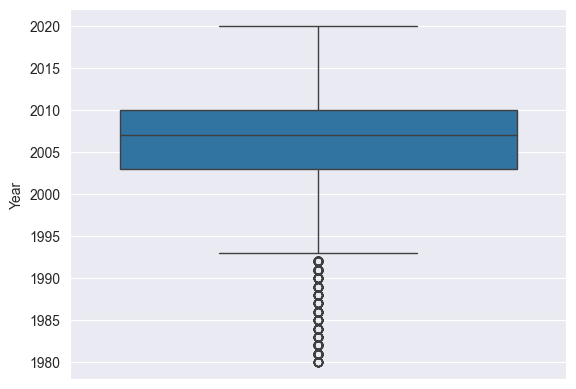

In [36]:
print(df['Year'].median)
sns.boxplot(df['Year'])
plt.show()

In [ ]:
df['Publisher'].value_counts()

In [37]:
df['Year'] =  df['Year'].fillna(df['Year'].median())
df['Publisher'] = df['Publisher'].fillna('Other')

In [56]:
platform_battles = df.groupby('Platform')['Global_Sales'].max().sort_values(ascending=False)

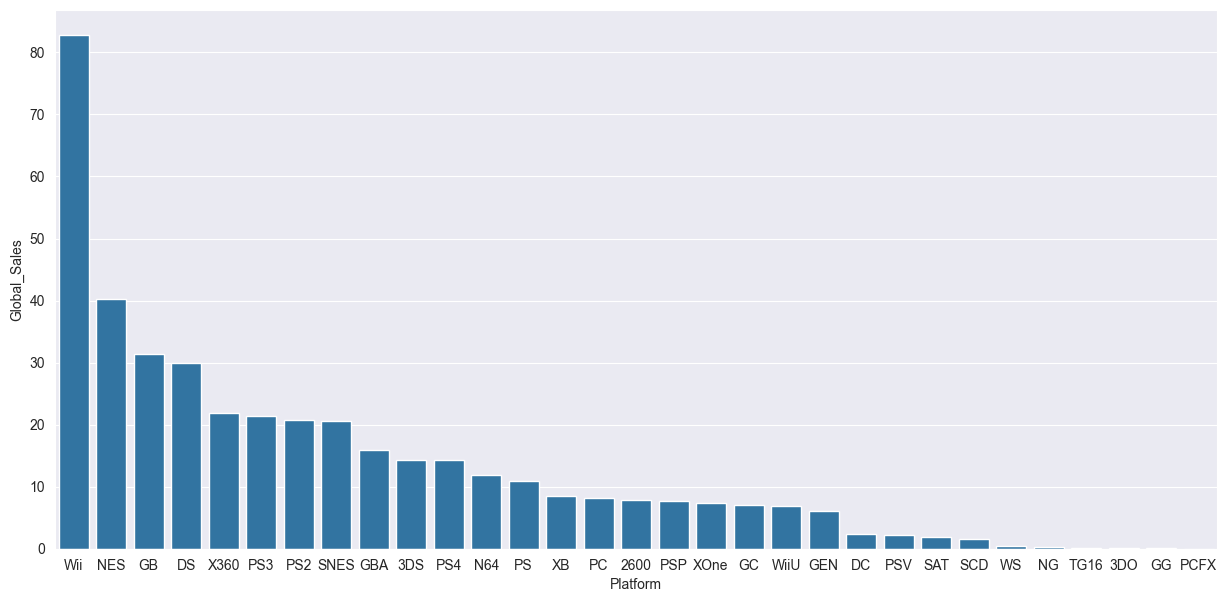

In [61]:
plt.figure(figsize = (15,7))
sns.barplot(platform_battles)
plt.show()

<Axes: >

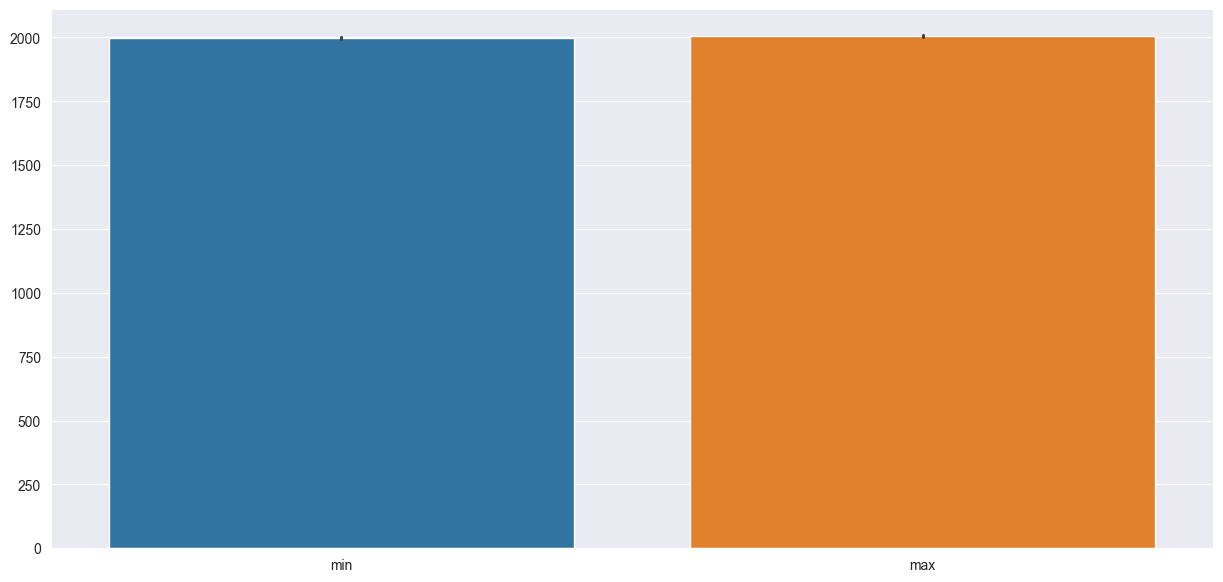

In [70]:
life_cycle = df.groupby('Platform')['Year'].agg(['min', 'max'])
plt.figure(figsize = (15,7))
sns.barplot(life_cycle)